# Ускорение и оптимальные методы (20 баллов)

In [420]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import itertools
import math

seed = 57
rng = np.random.default_rng(seed)

## Основная часть (10 баллов)

Рассмотрим задачу минимизации эмпирического риска (Empirical Risk Minimization):

$$
\min_{x \in \mathbb{R}^d} \left[ f(x) = \frac{1}{n} \sum_{i=1}^n \ell \left(g(x, a_i), b_i \right) + \frac{\lambda}{2} \| x \|^2_2 \right],
$$

где:
- $\ell(\cdot, \cdot) : \mathbb{R} \times \mathbb{R} \to \mathbb{R}$ — функция потерь на одном элементе;
- $g(\cdot, \cdot) : \mathbb{R}^{d} \times \mathbb{R}^{d} \to \mathbb{R}$ — модель;
- $x \in \mathbb{R}^d$ — вектор параметров модели;
- $\{ a_i \}_{i = 1}^n \in \mathbb{R}^{d}$ — векторы признаков $\left(\text{при транспонировании образуют в совокупности строки дата-матрицы}~ A \in \mathbb{R}^{n \times d}\right)$;
- $\{ b_i \}_{i = 1}^n \in \mathbb{R}$ — целевые значения $\left(\text{в совокупности образующие таргет-вектор }b \in \mathbb{R}^n\right)$;
- $\lambda > 0$ — параметр регуляризации.

В данной домашней работе предлагается рассмотреть в качестве
- модели $g(\cdot, \cdot)$ комбинацию _линейной_ и _логистической_ (или _сигмоидной_) функций:

$$
g(x, a_i) = \frac{1}{1 + \exp \left[- \langle x, a_i \rangle\right]};
$$

- функции потерь на одном элементе $\ell(\cdot, \cdot)$ _кросс-энтропию_:

$$
\ell(g(x, a_i), b_i) = -b_i \log \left[g(x, a_i)\right] - (1 - b_i) \log \left[1 -  g(x, a_i)\right].
$$

__Задача 1.__ Прежде чем мы перейдем к оптимизационным методам, вычислим все основные константы, а также произведем небольшой препроцессинг данных.


__а) (0.5 балла)__ Докажите, что градиент функции $f(x)$ равен

$$
\nabla f(x) = \frac{1}{n} \sum_{i=1}^n (g(x, a_i) - b_i) a_i + \lambda x.
$$

__Решение__

Найдем дифференциал $f(x) = \frac{1}{n} \sum_{i=1}^n \ell \left(g(x, a_i), b_i \right) + \frac{\lambda}{2} \| x \|^2_2$

$$
\mathrm{d}f = \frac{1}{n} \sum_{i=1}^n \frac{\partial l}{\partial g} \mathrm{d}g + \frac{\lambda}{2} \mathrm{d}\langle x, x\rangle
$$

Сделав замену $\xi = \langle x, a_i\rangle$ и воспользовавшись свойством логистической функции $\sigma^\prime(x) = (1 - \sigma(x))\sigma(x)$ получим (здесь и далее аргумент функции $g(x, a_i)$ опущен для компактности):
$$
\mathrm{d}g = g(1-g)\langle a, dx\rangle
$$

$$
\frac{\partial l}{\partial g} = -b_i\frac{1}{g} + (1-b_i)\frac{1}{1-g} = \frac{-b_i + g}{g(1-g)}
$$

Учитывая что $\langle x, x\rangle = 2\langle x, dx \rangle$ и подставляя в изначальное получаем

$$
\mathrm{d}f = \langle \frac{1}{n} \sum_{i=1}^n (g - b_i)a_i + \lambda x, \mathrm{d}x\rangle 
$$

ч.т.д.

__б) (1 балл)__ Докажите, что константа Липшица градиента $L$ может быть оценена как:

$$
L \geq \frac{1}{4n} \lambda_{\max} \left[A^\top A \right] + \lambda,
$$

где $A$ — дата-матрица, определенная в начале работы.

__Решение__

Будем пользоваться выражением для гессиана из пункта в. Для начала заметим, что:

$$
\sum_{i=1}^n a_i a_i^\top = \begin{pmatrix} a_1 & a_2 & \dots & a_n \end{pmatrix} \begin{pmatrix} a_1^\top \\ a_2^\top \\ \dots \\ a_n^\top \end{pmatrix} \overset{\text{def}}{=} A^\top A
$$

Оценим теперь величину $g(1-g)$. Это парабола с ветвями вниз с глобальным максимумом $\frac{1}{4}$. Таким образом получаем

$$
\frac{1}{n} \sum_{i=1}^n g(x, a_i)(1 - g(x, a_i)) a_i a_i^\top \preceq \frac{1}{4n} A^\top A
$$

Отсюда, пользуясь $\nabla^2 f(x) \preceq LI_d$ , аналогично предыдущему дз получаем требуемую оценку

__в) (0.5 балл)__ Докажите, что гессиан функции $f(x)$ равен

$$
\nabla^2 f(x) = \frac{1}{n} \sum_{i=1}^n g(x, a_i)(1 - g(x, a_i)) a_i a_i^\top + \lambda I_d.
$$

__Решение__

Найдем второй дифференциал:

$$
\mathrm{d}^2 f = \langle \frac{1}{n}\sum_{i=1}^n a_i \mathrm{d}g + \lambda \mathrm{d}x , \mathrm{d} x_1 \rangle = \langle g(1-g)\langle a_i, dx \rangle a_i + \lambda \mathrm{d}x, dx_1 \rangle
$$

Для преобразования первого слагаемого воспользуемся цепочкой равенств:

$$
\langle a_i \langle a_i, \mathrm{d}x \rangle , \mathrm{d}x_1 \rangle = \langle a_i a_i^\top \mathrm{d}x, \mathrm{d}x_1\rangle = \langle \mathrm{d}x, a_i a_i^\top \mathrm{d}x_1 \rangle 
$$

Таким образом

$$
\mathrm{d}^2 f = \langle (\frac{1}{n}\sum_{i=1}^n g(1-g)a_i a_i^\top + \lambda)\mathrm{d}x_1, \mathrm{d}x\rangle
$$

ч.т.д.

__г) (1  балл)__ Докажите, что константа сильной выпуклости $\mu$ может быть оценена как:

$$
\mu \leq \lambda,
$$

где $A$ — дата-матрица, определенная в начале работы.

__Решение__

По критерию выпуклости $\mu I_d \preceq \nabla^2 f = \frac{1}{n}g(1-g) A^\top A + \lambda I_d$. Т.к. $g$ - логистическая функция $g \in [0, 1]$ - на этом промежутке $g(1-g) \geq 0$. Известно, что $\forall A \in \mathbb{R}^d: \ A^\top A \succeq 0$. Таким образом первое слагаемое - положительно полуопределенное. Тогда изначальное неравенство можно успростить до $\mu I_d \preceq \lambda I_d$, ч.т.д.

__д)__ В качестве дата-матрицы $A$ и целевого вектора $b$ рассмотрим данные из датасета [_mushrooms_](https://github.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/blob/ПМИ_осень_2025/Datasets/mushrooms.txt). Ниже представлена функция загрузки датасета.

In [421]:
url = "https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/%D0%9F%D0%9C%D0%98_%D0%BE%D1%81%D0%B5%D0%BD%D1%8C_2025/Datasets/mushrooms.txt"
!wget -O mushrooms.txt "$url"

--2026-03-05 00:05:15--  https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/%D0%9F%D0%9C%D0%98_%D0%BE%D1%81%D0%B5%D0%BD%D1%8C_2025/Datasets/mushrooms.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 879712 (859K) [text/plain]
Saving to: ‘mushrooms.txt’

mushrooms.txt       100%[===================>] 859,09K  1,01MB/s    in 0,8s    

2026-03-05 00:05:17 (1,01 MB/s) - ‘mushrooms.txt’ saved [879712/879712]



In [422]:
from sklearn.datasets import load_svmlight_file

#файл должен лежать в той же директории, что и notebook
dataset = "mushrooms.txt"

data = load_svmlight_file(dataset)
A, b = data[0].toarray(), data[1]

# Необходимое линейное преобразование, которое меняет изначальные метки классов на 0 и 1
b = b - 1 

__e) (0.1  балла)__ C помощью функции ```train_test_split``` разделите датасет в отношении 4 к 1 (обучающая выборка должна быть в 4 раза больше, чем тестовая). Поставьте параметр ```random_state = 57```. В дальнейшем мы будем валидировать процесс обучения на тестовой выборке.

In [423]:
A, b

(array([[0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(8124, 112)),
 array([0., 1., 1., ..., 1., 0., 1.], shape=(8124,)))

In [424]:
# Ваше решение (Code)

from sklearn.model_selection import train_test_split
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=57)

A_train.shape, A_test.shape, b_train.shape, b_test.shape, 

((6499, 112), (1625, 112), (6499,), (1625,))

__ж) (0.1  балла)__ Для обучающей части $A_{train}$, $b_{train}$ оцените константы $L$ и $\mu$, положив равенство в полученной ранее оценке. Задайте $\lambda$ так, чтобы $\lambda \approx L / 1000$.

In [425]:
# Ваше решение (Code)
L = 1/(4*len(A_train))*np.max(np.linalg.eig(A_train.T @ A_train)[0])
L = np.real(L)
lambda_value = 1/1000 * L
mu = lambda_value

assert math.isclose(L, 2.586914976545057,  rel_tol=1e-6),  "Константа L-гладкости найдена неверно"
assert math.isclose(mu, 0.002586914976545057, rel_tol=1e-6),  "Константа регуляризации найдена неверно"

In [426]:
L, mu, lambda_value

(np.float64(2.5869149765450565),
 np.float64(0.0025869149765450567),
 np.float64(0.0025869149765450567))

__з) (0.3  балла)__ Дополните функции подсчета сигмоиды, кросс-энтропии и градиента оптимизируемой функции.

In [427]:
def sigmoid(x):
    """
    Вычисляет сигмоидную функцию.

    Параметры:
        x (np.array): Входное значение

    Возвращает:
        sigmoid (np.array) Значение сигмоидной функции для входных данных
    """
    
    #x = np.clip(x, -500, 500)
    return np.clip(1/(1+np.exp(-x)), 1e-15, 1 - 1e-15)


def loss(x, A=A_train, b=b_train, lambda_value=L/1000):
    """
    Вычисляет значение эмпирического риска.

    Параметры:
        x (np.array): Вектор параметров модели
        A (np.array): Матрица признаков обучающей выборки
        b (np.array): Вектор меток обучающей выборки
        lambda_value (float): Параметр регуляризации

    Возвращает:
        loss (float): Значение функции потерь
    """
    
    # YOUR CODE HERE
    
    l = -np.mean(b*np.log(sigmoid(A @ x)) + (1-b)*np.log(1 - sigmoid(A @ x))) + lambda_value/2*np.linalg.norm(x)**2
    '''
    for (i, a_i) in A:
        l-=(b[i]*np.log(sigmoid(x @ a_i)) + (1-b[i])*np.log(1 - sigmoid(x @ a_i)))
    '''
    return l


def grad(x, A=A_train, b=b_train, lambda_value=L/1000):
    """
    Вычисляет градиент функции потерь.

    Параметры:
        x (np.array): Вектор параметров модели
        A (np.array): Матрица признаков обучающей выборки
        b (np.array): Вектор меток обучающей выборки
        lambda_value (float): Параметр регуляризации

    Возвращает:
        grad (np.array): Градиент функции потерь
    """
    
    g = np.sum((sigmoid(A @ x) - b).reshape(-1, 1) * A, axis=0)/A.shape[0] + lambda_value*x
    
    return g

__Задача 2.__ Теперь, когда мы закончили с препроцессингом и реализацией основных функций, перейдем к ускоренным методам.

__a) (1.5 балла)__ Реализуйте метод тяжелого шарика.

**Псевдокод алгоритма**

---

_Инициализация:_

- Размер шага $\{ \gamma_k \}_{k=0} > 0$.
- Параметр момента $\{ \tau_k \}_{k=0} \in [0, 1]$.
- Начальная точка $x^0 = x^{-1} \in \mathbb{R}^d$.
- Максимальное число итераций $K$.

---

$k$_-ая итерация_:

   $$x^{k+1} = x^k - \gamma_k \nabla f \left(x^k\right) + \tau_k \left(x^k - x^{k-1}\right)$$

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$ или $\| \nabla f\left(x^k\right) \|_2 < \varepsilon$

---

_Выход:_
- Полученное значение $x^K$

In [432]:
def criterion(x, A=A_train, b=b_train, lambda_value=L/1000):
    """
    Вычисляет критерий остановки.

    Параметры:
        x (np.array): Текущая точка
        A (np.array): Матрица признаков
        b (np.array): Вектор меток
        lambda_value (float): Параметр регуляризации

    Возвращает:
        norm (float): Норма градиента
    """

    return np.linalg.norm(grad(x, A, b, lambda_value))

In [433]:
def heavy_ball(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, **params):
    """
    Реализация метода тяжелого шарика.

    Параметры:
        A (np.array): Матрица признаков.
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        grad (Callable): Функция вычисления градиента
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка
        eps (float): Точность сходимости (критерий остановки)
        max_iter (int): Максимальное количество итераций
        params : Именованные гиперпараметры метода
            params['gamma'](k): шаг на k-ой итерации
            params['tau'](k): моментум на k-ой итерации

    Возвращает:
        x_k (np.array): Найденное решение
        values (list): Список значений x_k на каждой итерации
        errors (list): Список значений критерия сходимости на каждой итерации
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    x_k_prev = np.copy(x_0)
    values.append(x_k)
    values.append(x_k_prev)
    errors.append(criterion(x_k, A, b, lambda_value))

    for k in tqdm(range(max_iter)):
        
        grad_step = params['gamma'](k)*grad(x_k, A, b, lambda_value)
        momentum = params['tau'](k)*(x_k - values[-2])
        #print(grad_step.shape, momentum.shape)
        x_k = x_k - grad_step + momentum

        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

Запустите метод тяжелого шарика на обучающей выборке ERM. Для этого используйте следующие значение параметров:

- Положите шаг равным $\frac{1}{L}$;
- Рассмотрите моментум `tau` = $\frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$, а также моментумы: $[0.8\tau, 0.9\tau, 0.95\tau, 1.05\tau, 1.2\tau]$;
- Стартовая точка $x^0$ одинаковая для всего задания, ее генерация приложена ниже;
- Положите максимальное число итераций равным $10^3$;
- Значение критерия остановки положите равным $10^{-8}$;

In [434]:
x_0 = rng.random(A_train.shape[1])

In [435]:
# Ваше решение (Code)
gamma = lambda x: 1/L
tau = (np.sqrt(L) - np.sqrt(mu))/(np.sqrt(L) + np.sqrt(mu))
coeffs = np.array([0.8, 0.9, 0.95, 1, 1.05, 1.2])
tau*coeffs

array([0.75095451, 0.84482383, 0.89175848, 0.93869314, 0.9856278 ,
       1.12643177])

In [436]:
def plot_for_scaled_taus(A, b, lambda_value, grad, criterion, x_0, gamma, tau, coeffs, optimizer=heavy_ball):

    for coef in coeffs:

        tau_func = lambda k, coef=coef: coef*tau

        print(f"Calculating for k={coef}")
        x, values, errors = optimizer(A, b, lambda_value, grad, criterion, x_0, 1e-8, 1000, gamma=gamma, tau=tau_func)
        iters = np.arange(len(errors))

        plt.plot(iters, errors, label=fr"$\tau = {coef}\cdot\tau$")

    plt.ylabel("Ошибка")
    plt.xlabel("Итерация")
    plt.grid()
    plt.legend()

Постройте сравнительный график.

Calculating for k=0.8


100%|██████████| 1000/1000 [00:04<00:00, 237.39it/s]


Calculating for k=0.9


100%|██████████| 1000/1000 [00:03<00:00, 281.03it/s]


Calculating for k=0.95


...

 57%|█████▋    | 572/1000 [00:02<00:01, 277.26it/s]


Calculating for k=1.05


100%|██████████| 1000/1000 [00:04<00:00, 236.38it/s]


Calculating for k=1.2


  3%|▎         | 29/1000 [00:00<00:03, 280.84it/s]/tmp/ipykernel_1691080/2692593839.py:13: RuntimeWarning: overflow encountered in exp
  return np.clip(1/(1+np.exp(-x)), 1e-15, 1 - 1e-15)
100%|██████████| 1000/1000 [00:03<00:00, 262.06it/s]


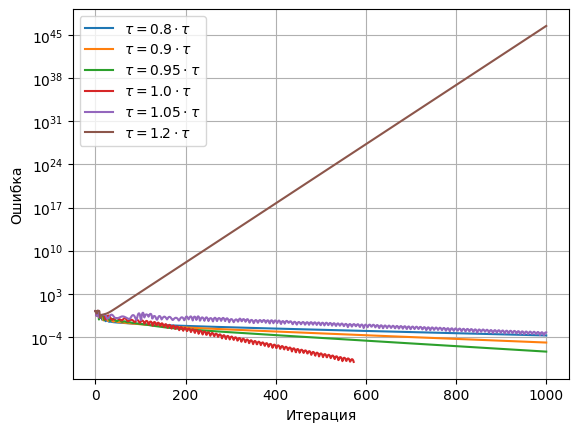

In [437]:
# Ваше решение (Code)
plot_for_scaled_taus(A_train, b_train, lambda_value, grad, criterion, x_0, gamma, tau, coeffs)
plt.yscale("log")
plt.show()

__б) (1 балл)__ Постройте сравнительный график, только теперь значение моментума будет зависеть от номера итерации. Сравните сходимости при
- $\tau = \frac{k}{k + 20}$;
- $\tau = \frac{k}{k + 10}$;
- $\tau = \frac{k}{k + 5}$;
- $\tau = \frac{k}{k + 1}$;
- Наилучший $\tau = const$.

In [438]:
denom = [20, 10, 5, 1]

In [439]:
def plot_for_adaptive_taus(A, b, lambda_value, grad, criterion, x_0, gamma, denom):

    for d in denom:

        tau_func = lambda k, d=d: k/(k+d)

        print(f"Calculating for d={d}")
        x, values, errors = heavy_ball(A, b, lambda_value, grad, criterion, x_0, 1e-8, 1000, gamma=gamma, tau=tau_func)
        iters = np.arange(len(errors))

        plt.plot(iters, errors, label=fr"$\tau = \frac{{k}}{{k + {d}}}$")

    plt.ylabel("Ошибка")
    plt.xlabel("Итерация")
    plt.grid()
    plt.legend()

Calculating for d=20


 86%|████████▌ | 858/1000 [00:05<00:00, 168.74it/s]


Calculating for d=10


100%|██████████| 1000/1000 [00:06<00:00, 158.01it/s]


Calculating for d=5


100%|██████████| 1000/1000 [00:04<00:00, 219.57it/s]


Calculating for d=1


 57%|█████▋    | 572/1000 [00:02<00:01, 278.52it/s]


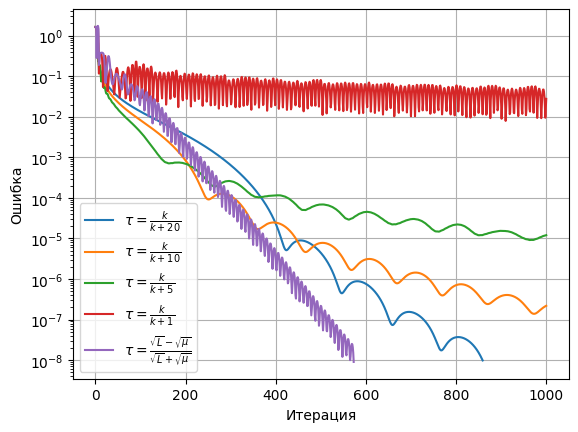

In [440]:
# Ваше решение (Code)
plot_for_adaptive_taus(A_train, b_train, lambda_value, grad, criterion, x_0, gamma, denom)

best_tau = lambda x: tau
x, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, 1e-8, 1000, gamma=gamma, tau=best_tau)
iters = np.arange(len(errors))
plt.plot(iters, errors, label=r"$\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$")
plt.legend()
plt.yscale("log")
plt.show()

__в) (1 балл)__ Сравните метод тяжелого шарика с обычным градиентным спуском. Для этого реализуйте метод градиентного спуска, а сравнения проведите для лучшего значения моментума в методе тяжелого шарика со следующими значениями шагов (для каждого из методов):

- $\gamma_k = \frac{1}{2L}$,

- $\gamma_k = \frac{1}{L}$,

- $\gamma_k = \frac{2}{L}$,

- $\gamma_k = \frac{2}{\mu + L}$.



In [441]:
def gradient_descent(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, **params):
    """
    Реализация градиентного спуска.

    Параметры:
        A (np.array): Матрица признаков.
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        grad (Callable): Функция вычисления градиента
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка
        eps (float): Точность сходимости (критерий остановки)
        max_iter (int): Максимальное количество итераций
        params : Именованные гиперпараметры метода
            params['gamma'] : шаг на k-ой итерации

    Возвращает:
        x_k (np.array) : Найденное решение
        values (list) : Список значений x_k на каждой итерации
        errors (list) : Список значений критерия сходимости на каждой итерации
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    values.append(x_k)
    errors.append(criterion(x_k, A, b, lambda_value))

    for k in tqdm(range(max_iter)):

        gamma = params['gamma'](k)
        x_k = x_k - gamma*grad(x_k, A, b)

        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

In [442]:
# Ваше решение (Code)
def plot_for_steps(A, b, lambda_value, grad, criterion, x_0, gammas, ks):

    for d, gamma in enumerate(gammas):

        x, values, errors = gradient_descent(A, b, lambda_value, grad, criterion, x_0, 1e-8, 1000, gamma=gamma)
        iters = np.arange(len(errors))

        plt.plot(iters, errors, label=fr"$\gamma_k$ = {ks[d]}" + r"$\frac{1}{L}$")

    plt.ylabel("Ошибка (log)")
    plt.xlabel("Итерация")
    plt.grid()

100%|██████████| 1000/1000 [00:03<00:00, 275.09it/s]


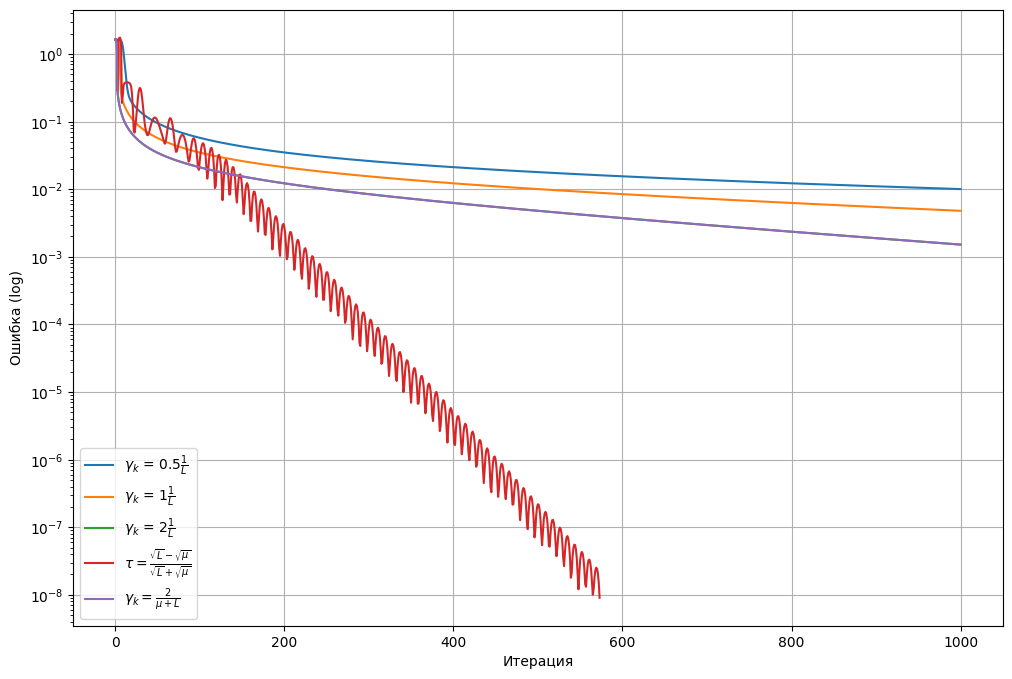

In [443]:
# Ваше решение (Code)

ks = [1/2, 1, 2]
gammas = [lambda x, k=k: k*1/L for k in ks]

plt.figure(figsize=(12, 8))
plot_for_steps(A_train, b_train, lambda_value, grad, criterion, x_0, gammas, ks)

x, values, errors = heavy_ball(A_train, b_train, lambda_value, grad, criterion, x_0, 1e-8, 1000, gamma=gamma, tau=best_tau)
iters = np.arange(len(errors))
plt.plot(iters, errors, label=r"$\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$")

x, values, errors = gradient_descent(A_train, b_train, lambda_value, grad, criterion, x_0, 1e-8, 1000, gamma=lambda x: 2/(mu+L))
iters = np.arange(len(errors))
plt.plot(iters, errors, label=r"$\gamma_k = \frac{2}{\mu + L}$")

plt.yscale("log")
plt.legend()
plt.show()

__г) (1.5 балла)__ Реализуйте ускоренный градиентный метод.

**Псевдокод алгоритма**

---

_Инициализация:_

- Размер шага $\{ \gamma_k \}_{k=0} > 0$
- Параметр момента $\{ \tau_k \}_{k=0} \in [0, 1]$
- Начальная точка $x^0 = x^{-1} \in \mathbb{R}^d$
- Максимальное число итераций $K$

---

$k$_-ая итерация_:

1. Обновить точку для следующего градиента:
   $$y^k = x^k + \tau_k \left(x^k - x^{k - 1} \right)$$

2. Сделать шаг градиентного спуска:
   $$x^{k+1} = y^k - \gamma_k \nabla f \left(y^k \right)$$

---

_Условие остановки:_

- Достигнуто максимальное число итераций $K$ или $\| \nabla f \left(x^k\right) \| < \varepsilon$

---

_Выход:_

- Полученное значение $x^K$

In [444]:
def NAG(A, b, lambda_value, grad, criterion, x_0, eps, max_iter, **params):
    """
    Реализация метода ускоренного градиента Нестерова.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        grad (Callable): Функция вычисления градиента в точке
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка оптимизации
        eps (float): Точность сходимости
        max_iter (int): Максимальное количество итераций
        params : Именованные гиперпараметры метода
            params['gamma'](k) : функция шага на k-ой итерации
            params['tau'](k) : функция момента на k-ой итерации

    Возвращает:
        x_k (np.array) : Найденное решение
        values (list) : Список значений x_k на каждой итерации
        errors (list) : Список значений критерия сходимости на каждой итерации
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    values.append(x_k)
    x_k_old = np.copy(x_0)
    values.append(x_k_old)
    errors.append(criterion(x_k, A, b, lambda_value))

    for k in tqdm(range(max_iter)):

        y_k = x_k + params['tau'](k)*(x_k - values[-2])
        x_k = y_k - params['gamma'](k)*grad(y_k)

        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

Сравните его с методом тяжёлого шарика при тех же значениях моментума, что и в пункте __а)__.

In [445]:
coeffs

array([0.8 , 0.9 , 0.95, 1.  , 1.05, 1.2 ])

Calculating for k=0.8


100%|██████████| 1000/1000 [00:04<00:00, 222.85it/s]


Calculating for k=0.9


100%|██████████| 1000/1000 [00:04<00:00, 234.48it/s]


Calculating for k=0.95


...

 52%|█████▏    | 523/1000 [00:02<00:01, 258.89it/s]


Calculating for k=1.05


100%|██████████| 1000/1000 [00:03<00:00, 286.38it/s]


Calculating for k=1.2


  3%|▎         | 32/1000 [00:00<00:10, 95.47it/s] /tmp/ipykernel_1691080/2692593839.py:13: RuntimeWarning: overflow encountered in exp
  return np.clip(1/(1+np.exp(-x)), 1e-15, 1 - 1e-15)
100%|██████████| 1000/1000 [00:03<00:00, 261.98it/s]


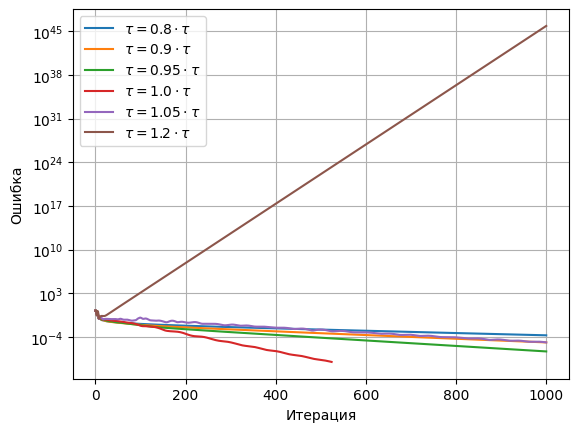

In [446]:
# Ваше решение (Code)
plot_for_scaled_taus(A_train, b_train, lambda_value, grad, criterion, x_0, gamma, tau, coeffs, optimizer=NAG)
plt.yscale("log")
plt.legend()
plt.show()

__д) (0.5 балла)__ Наблюдать уменьшение критерия сходимости, конечно, замечательно, но хочется провалидироваться на тестовых данных. Для этого необходимо подсчитать отношение правильно предсказанных меток классов к их общему числу (метрика _accuracy_). Предложите способ, как оценить значение этой метрики. Помните, что функция $g(x, a_i)$ возвращает значение в диапазоне от 0 до 1.

__Решение__
Будем воспринимать результат $g(x, a_i)$ как вероятность того, что данные принадлежать к одному из классов (если accuracy будет менее 0.5 значит мы не угадали метки и accuracy на самом деле 1-accuracy). Для этого выберем некоторую границу (threshold) и если $g \geq threshold$ считаем что a_i имеет метку, сказанную выше (и обратную иначе). Таким методом проходимся по всей тестовой выборке, сравнивая наши предсказания с правильными

__е) (1 балл)__ Постройте графики значения метрики _accuracy_ для градиентного спуска, метода тяжёлого шарика и ускоренного градиентного спуска. Положите шаг равным $\frac{1}{L}$, а значение моментума подберите для каждого метода таким, на котором наблюдалась лучшая сходимость.

In [447]:
# Ваше решение (Code)
eps=1e-8
max_iter = 1000

gamma = lambda x: 1/L
tau_ball = lambda x: tau
_, values_ball, _ = heavy_ball(A_test, b_test, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=gamma, tau=tau_ball)

gamma_GD = lambda x: 2/(mu+L)
_, values_GD, _ = gradient_descent(A_test, b_test, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=gamma_GD)

#tau_NAG = lambda x: 0.95*tau
_, values_NAG, _ = NAG(A_test, b_test, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=gamma, tau=tau_ball)

100%|██████████| 1000/1000 [00:02<00:00, 417.62it/s]


In [448]:
np.array(values_ball).shape

(565, 112)

In [449]:
#я знаю что это плохо читается, но я обожаю длинные строки в нампае и торче
acc_ball = (((sigmoid(A_test @ np.array(values_ball).T)>=0.5).T) == b_test).astype(int).sum(axis=1)/len(b_test)
acc_GD = (((sigmoid(A_test @ np.array(values_GD).T)>=0.5).T) == b_test).astype(int).sum(axis=1)/len(b_test)
acc_NAG = (((sigmoid(A_test @ np.array(values_NAG).T)>=0.5).T) == b_test).astype(int).sum(axis=1)/len(b_test)

(-5.0, 400.0)

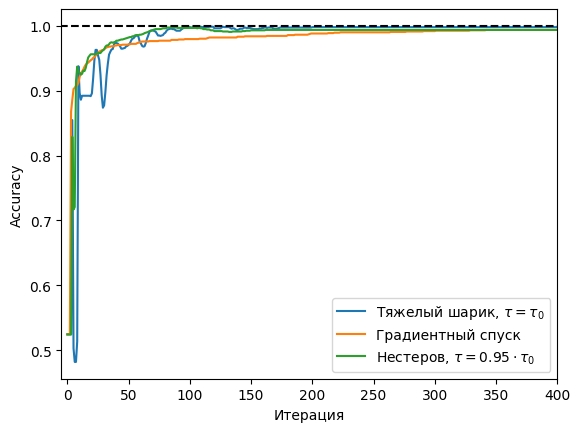

In [468]:
iters = np.arange(len(acc_ball))
plt.plot(iters, acc_ball, label = r"Тяжелый шарик, $\tau = \tau_0$")
iters = np.arange(len(acc_GD))
plt.plot(iters, acc_GD, label="Градиентный спуск")
iters = np.arange(len(acc_NAG))
plt.plot(iters, acc_NAG, label=r"Нестеров, $\tau = 0.95\cdot\tau_0$")

plt.hlines(1.0, -6, 1000, linestyle="dashed", color="black")

plt.legend()
plt.xlabel("Итерация")
plt.ylabel("Accuracy")

plt.xlim(-5, 400)

## Дополнительная часть (10 баллов)

__Задача 3.__ До этого, в рамках метода градиентного спуска, мы использовали константный и зависящий от номера итерации шаг. В случае неоптимального подбора, алгоритм может требовать сильно большее число итераций для достижения сходимости. Отсюда возникает идея использовать шаги, которые бы зависели от некоторых параметров функции.

Сделаем так: будем искать такой шаг $\gamma_k$ в точке $x^k$, чтобы значение функции в следующей точке было достаточно малым (относительно текущей точки). В идеале, мы хотим решить следующее:

$$
\gamma_k = \arg \min_{\gamma_k} f \left(x^k + \gamma_k h^k \right),~ \text{где $h^k$ — это направление куда мы хотим двигаться.}
$$

Этот алгоритм в общем виде называется _линейный поиск_. Для градиентного спуска $h^k$ — это просто антиградиент.

Как нетрудно заметить, основная проблема заключается в том, что отрешивать $\arg \min$ на каждой итерации спуска — вычислительно сложная задача, которая хоть и даст улучшение по числу итераций, но сильно повысит временные затраты алгоритма. В данной задаче мы изучим различные методы поиска $\gamma_k$, которые начинают с некоторого стартового шага $\gamma_0$ и уменьшают его до тех пор, пока не выполнится необходимое условие приемлемости шага.

__а) (2 балла)__ Первым рассмотрим условие Армихо. Эта стратегия основывается на следующей идее: мы хотим из точки $x^k$ попасть в такую точку $x^{k+1}$, что значение функции в ней достаточно мало по сравнению со значением функции в текущей точке. Но под "достаточно мало" мы понимаем не просто уменьшение, а уменьшение с определённой скоростью, соответствующей направлению спуска. Чтобы это количественно формализовать, будем сравнивать значение функции в новой точке с значением касательной прямой, проведённой в точке $x^k$ в направлении $h^k$. Если новая точка оказывается ниже этой прямой — шаг подходит. Для надёжности наклон касательной немного уменьшают, домножая на коэффициент $\beta_1 \in (0, 1)$, чтобы не требовать слишком сильного убывания и избежать отбрасывания хороших шагов.

Из вышесказанного получается следующее условие:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f(x^k), h^k \rangle.
$$

Это неравенство можно получить, записав линейное приближение функции $f\left(x^k + \gamma_k h^k \right)$ до первого порядка разложения в точке $x^k$, и затем требуя, чтобы значение функции не просто уменьшилось, а оказалось ниже этого приближения с некоторым запасом.

В случае градиентного спуска $h^k = -\nabla f\left(x^k\right)$ неравенство принимает вид:

$$
f\left(x^k - \gamma_k \nabla f\left( x^k \right)\right) \leq f\left(x^k\right) - \beta_1 \gamma_k \left\| \nabla f\left(x^k\right) \right\|_2^2.
$$

Для удобства, допишите общий метод `gradient_descent_optimal_steps`, который будет принимать в себя различные правила поисков шага (`line_search`), а также напишите функцию `armijo`, вычисляющую приближенное значение $\gamma_k$ за определенное количество итераций.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметр $\beta_1 \in (0, 1)$

---

1. Проверить условие Армихо:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f(x^k), h^k \rangle
$$

2. Если условие выполнено — вернуть $\gamma_k$. Иначе — уменьшить шаг:

    $$
    \gamma_k = m \cdot \gamma_k
    $$

    и вернуться к 1.

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [451]:
def gradient_descent_optimal_steps(A, b, lambda_value, loss, grad, line_search, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, **params):
    """
    Реализация градиентного спуска с оптимальным подбором шага.

    Параметры:
        A (np.array): Матрица признаков размерности
        b (np.array): Вектор целевых значений размерности
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь
        grad (Callable): Функция вычисления градиента
        line_search (Callable): Функция подбора шага
        criterion (Callable): Функция критерия остановки
        x_0 (np.array): Начальная точка оптимизации
        eps (float): Точность сходимости
        max_iter (int): Максимальное количество итераций
        params (dict): Дополнительные параметры для line_search:
            params['beta1'] (float): Первый параметр
            params['beta2'] (float): Второй параметр (не используется в правиле Армихо)
            params['gamma_mult'] (float): Множитель для уменьшения шага
            params['line_search_max_iter'] (int): Максимальное число итераций подбора шага
            params['gamma0'] (float): Начальное значение шага

    Возвращает:
        x_k (np.array): Найденное решение
        values (list): История значений x на каждой итерации
        errors (list): История значений критерия сходимости
    """
    values = []
    errors = []

    x_k = np.copy(x_0)
    values.append(x_k)
    errors.append(criterion(x_k, A, b, lambda_value))

    for k in tqdm(range(max_iter)):
        
        grad_x_k = grad(x_k, A, b)
        gamma = line_search(A, b, lambda_value, loss, grad, x_k, -grad_x_k, params['beta1'], params['beta2'],
           params['gamma_mult'], params['line_search_max_iter'], params['gamma0'])
        #gamma = 1/L
        x_k = x_k - gamma*grad_x_k
        values.append(x_k)
        errors.append(criterion(x_k, A, b, lambda_value))
        if errors[-1] < eps:
            break

    return x_k, values, errors

In [452]:
def armijo(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Правило Армихо.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь
        grad (Callable): Функция вычисления градиента
        x (np.array): Текущая точка
        h (np.array): Направление спуска
        beta1 (float): Параметр условия достаточного убывания
        beta2 (float): Не используется, оставлен для совместимости
        gamma_mult (float): Множитель уменьшения шага
        max_iters (int): Максимальное число итераций подбора
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Армихо
    """

    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:

        counter+=1
        if loss(x + gamma*h, A, b, lambda_value) <= current_loss + beta1*gamma*directional_derivative:
            break
        else:
            gamma = gamma_mult*gamma

    return gamma

Запустите градиентный спуск с правилом Армихо, рассмотрев разные значения для начальной инициализации $\gamma_0$ и базовыми значениями для других параметров:
- $\gamma_0 = 10^{-2}$ — стандартное значение;
- $\gamma_0 = 10^{-1}$;
- $\gamma_0 = 1$;
- $\gamma_0 = 5$.
- $\gamma_0 = 10$.
- $\gamma_0 = 15$.

В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметра $\beta_1$ возьмите $\beta_1 = 10^{-4}$.

 60%|██████    | 602/1000 [00:05<00:03, 105.92it/s]


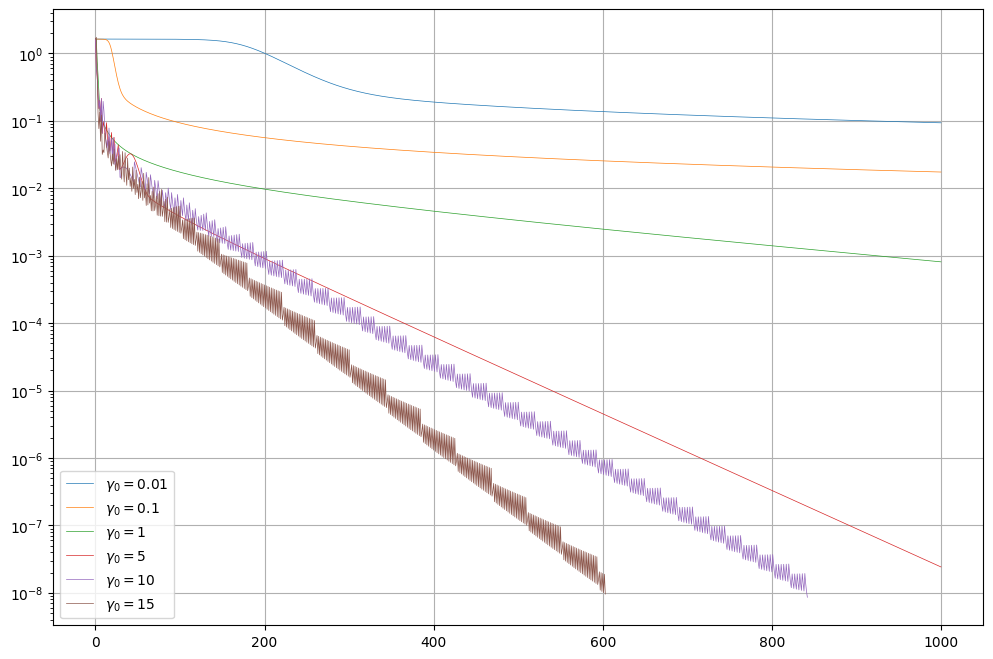

In [453]:
gammas0 = [1e-2, 1/10, 1, 5, 10, 15]

plt.figure(figsize=(12, 8))

for gamma0 in gammas0:

    _, _, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, armijo, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, gamma0=gamma0, gamma_mult=0.5, beta1=1e-1, beta2=None, line_search_max_iter=25)
    
    iters = np.arange(len(errors))
    plt.plot(iters, errors, label=fr"$\gamma_0 = {gamma0}$", linewidth=0.5)
plt.yscale("log")
plt.legend()
plt.grid()

Почему наблюдается худшая сходимость при меньших значениях $\gamma_0$?

__Решение__

Маллое значение $\gamma_0$ будет сразу удоволетворять условию Армихо, т.е. вместо поиска оптимального шага, мы получаем обычный градиентный спуск с постоянным малым шагом, который очевидно медленно сходится

P.S. Здесь взято $\beta_1 = 0.1$, в отличие от требуемого от задания, т.к. это понадобится в следующем пункте. В этом пункте это сильно поведение не меняет

__б) (2 балла)__ Хоть правило Армихо и отсекает некоторое количество неудачных шагов, всё же оно не определяет шаг строго — остаётся достаточно широкий выбор допустимых значений $\gamma$, удовлетворяющих неравенству. Это может привести к выбору слишком малого шага, особенно если взять $\gamma$ достаточно маленьким с самого начала — тогда условие Армихо будет выполнено, но скорость сходимости существенно снизится. Вы могли убедиться в этом в предыдущем пункте, где даже слишком маленький шаг удовлетворял критерию.

Чтобы избежать этой проблемы, используется _правило Гольдштейна_, которое сужает диапазон допустимых значений $\gamma$, добавляя нижнюю границу на приращение функции. Оно использует ту же линейную аппроксимацию, но требует, чтобы значение функции не было слишком маленьким — то есть, чтобы шаг не оказался чересчур осторожным. Условие Гольдштейна выглядит следующим образом:

$$
f\left(x^k\right) + \beta_2 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle \leq f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle,
$$

где $0 < \beta_1 < \beta_2 < 1$. Таким образом, выбираются такие $\gamma$, которые дают достаточное, но не чрезмерное убывание функции. Это может значительно ускорить сходимость, особенно на начальных этапах, когда длина шага критична для быстрого продвижения к минимуму.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметры $\beta_1, \beta_2 \in (0, 1)$

---

1. Проверить условие Гольдштейна:

$$
f\left(x^k\right) + \beta_2 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle \leq f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle
$$

2. Если условие выполнено — вернуть $\gamma_k$. Если не выполняется второе условие — уменьшить шаг:

    $$\gamma_k = \gamma_k \cdot m$$

    и вернуться к 1. Иначе — увеличить шаг:

    $$\gamma_k = \gamma_k / m$$

    и вернуться к 1

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [454]:
def goldstein(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Правило Гольдштейна.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь
        grad (Callable): Функция вычисления градиента
        x (np.array): Текущая точка
        h (np.array): Направление спуска
        beta1 (float): Параметр условия достаточного убывания
        beta2 (float): Параметр условия существенного убывания
        gamma_mult (float): Множитель уменьшения шага
        max_iters (int): Максимальное число итераций подбора
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Гольдштейна
    """
    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:

        counter+=1
        if current_loss + beta2*gamma*directional_derivative <= loss(x + gamma*h, A, b, lambda_value) and loss(x + gamma*h, A, b, lambda_value) <= current_loss + beta1*gamma*directional_derivative:
            break
        else:
            if not loss(x + gamma*h, A, b, lambda_value) <= current_loss + beta1*gamma*directional_derivative:
                gamma = gamma*gamma_mult
            else:
                gamma = gamma/gamma_mult

    return gamma

Запустите правило Гольдштейна с параметрами $\gamma_0$ из __а)__. В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметров $\beta_1$ и $\beta_2$ возьмите $\beta_1 = 10^{-4}$ и $\beta_2 = 1 - 10^{-4}$.

  0%|          | 0/1000 [00:00<?, ?it/s]

 60%|██████    | 602/1000 [00:09<00:05, 66.52it/s]


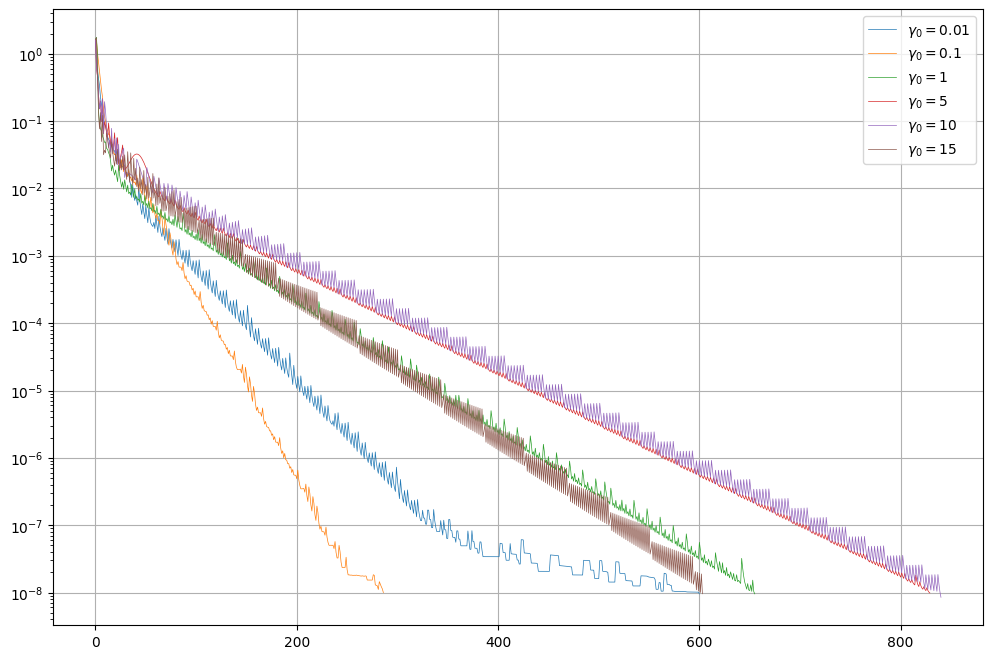

In [455]:
# Ваше решение (Code)

gammas0 = [1e-2, 1/10, 1, 5, 10, 15]

plt.figure(figsize=(12, 8))

for gamma0 in gammas0:

    _, _, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, goldstein, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, gamma0=gamma0, gamma_mult=0.5, beta1=1e-1, beta2=1-1e-1, line_search_max_iter=25)
    
    iters = np.arange(len(errors))
    plt.plot(iters, errors, label=fr"$\gamma_0 = {gamma0}$", linewidth=0.5)
plt.yscale("log")
plt.legend()
plt.grid()

Есть ли улучшение сходимости? Объясните, почему.

__Решение__

Улучшение сходимости есть, но только при больших $\beta_1$ (уже на 0.01) разницы не будет. При таких значениях $\beta$ мы идем максимально близко вдоль касательной - в этом случае само значение оптимального шага немного подрастает и при этом мы еще дополнительно не даем ему опускаться слишком низко засчет условия Гольдштейна. Отсюда лучшая сходимость.

__в) (2 балла)__ Условие Гольдштейна реализует наивное отсечение. Теперь рассмотрим точки, в которых наша функция не убывает так сильно, как в текущей. Конкретнее, нас интересуют такие значения шага, при которых производная по направлению $h^k$ не уменьшилась сильно по сравнению с тем, что было в начале, то есть:

$$
\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle \geq \beta_2 \langle \nabla f \left(x^k\right), h^k \rangle.
$$

Это условие называется условием кривизны (curvature condition). Его смысл — убедиться, что градиент в новой точке не стал слишком плоским по направлению $h^k$, то есть мы не зашли слишком далеко в область, где функция уже почти не меняется. Такое поведение может привести к медленной сходимости и ухудшению качества шага.

Правило Вольфа объединяет два требования: условие Армихо, которое гарантирует достаточное убывание функции, и условие кривизны, которое ограничивает чрезмерное затухание производной. Таким образом, шаг выбирается только в том случае, если оба этих условия выполняются одновременно.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметры $\beta_1, \beta_2 \in (0, 1)$

---

1. Проверить условие Армихо:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle
$$

2. Проверить условие кривизны

$$
\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle \geq \beta_2 \langle \nabla f \left(x^k\right), h^k \rangle
$$

2. Если оба условия выполняются, вернуть $\gamma_k$. Если не выполняется Армихо — уменьшить шаг:

    $$\gamma_k = \gamma_k \cdot m$$

    и вернуться к 1. Иначе — увеличить шаг:

    $$\gamma_k = \gamma_k / m$$

    и вернуться к 1

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [456]:
def wolfe(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Правило Вольфа.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь
        grad (Callable): Функция вычисления градиента
        x (np.array): Текущая точка
        h (np.array): Направление спуска
        beta1 (float): Параметр условия достаточного убывания
        beta2 (float): Параметр кривизны
        gamma_mult (float): Множитель уменьшения шага
        max_iters (int): Максимальное число итераций подбора
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию Вольфа
    """
    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:

        counter+=1
        if loss(x + gamma*h, A, b, lambda_value) <= current_loss + beta1*gamma*directional_derivative:
            if grad(x + gamma*h) @ h >= beta2*directional_derivative:
                break
            else:
                gamma = gamma/gamma_mult
        else:
            gamma = gamma*gamma_mult

    return gamma

Запустите правило Вольфа с параметрами $\gamma_0$ из __а)__. В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметров $\beta_1$ и $\beta_2$ возьмите $\beta_1 = 10^{-4}$ и $\beta_2 = 0.9$.

 65%|██████▌   | 654/1000 [00:13<00:06, 49.84it/s]


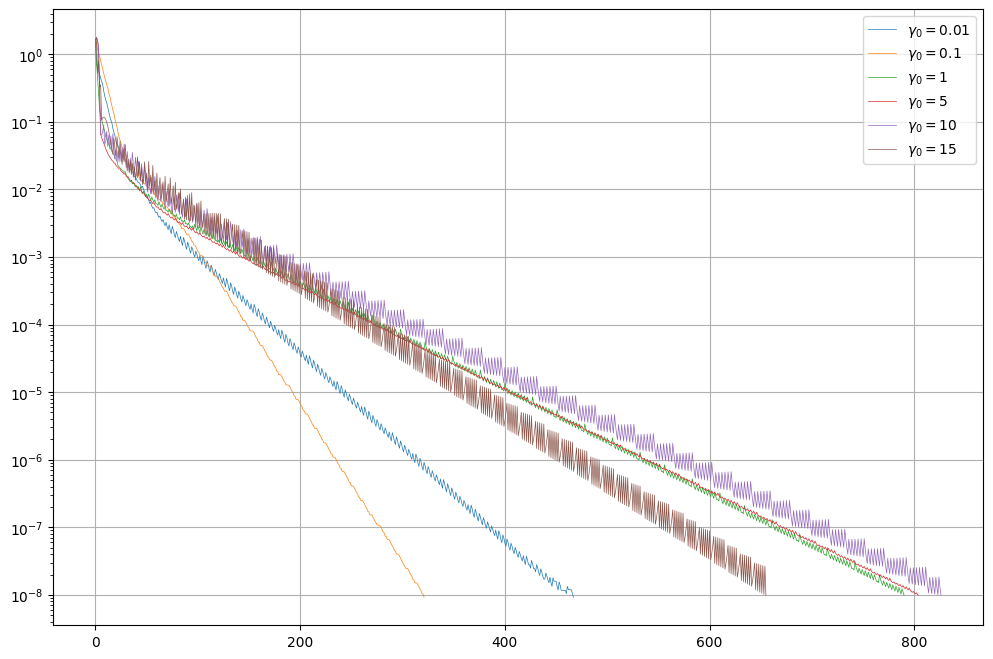

In [457]:
# Ваше решение (Code)
plt.figure(figsize=(12, 8))

gammas0 = [1e-2, 1/10, 1, 5, 10, 15]

for gamma0 in gammas0:

    _, _, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, wolfe, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, gamma0=gamma0, gamma_mult=0.5, beta1=1e-4, beta2=0.9, line_search_max_iter=20)
    
    iters = np.arange(len(errors))
    plt.plot(iters, errors, label=fr"$\gamma_0 = {gamma0}$", linewidth=0.5)
plt.yscale("log")
plt.legend()
plt.grid()

__г) (2 балла)__ Обычное условие кривизны может допускать ситуацию, когда производная по направлению в новой точке становится положительной, что приводит к тому, что неравенство всегда выполняется. Чтобы исключить этот случай, можно использовать модули для проверки абсолютного значения градиента:

$$
|\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle| \leq \beta_2 |\langle \nabla f \left(x^k\right), h^k \rangle|.
$$

Знак меняется, потому что справа мы имеем отрицательное значение, которое становится положительным. Мы хотим, чтобы абсолютное значение производной в новой точке было близким к нулю, так как в оптимуме градиент должен быть равен нулю, а это гарантирует, что шаг был выбран правильно и направлен в сторону минимума.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^k$
- Начальная точка $\gamma_0 > 0$
- Направление спуска $h^k$
- Максимальное число итераций $K$
- Множитель уменьшения шага $m \in (0, 1)$
- Параметры $\beta_1, \beta_2 \in (0, 1)$

---

1. Проверить условие Армихо:

$$
f\left(x^k + \gamma_k h^k\right) \leq f\left(x^k\right) + \beta_1 \gamma_k \langle \nabla f\left(x^k\right), h^k \rangle
$$

2. Проверить сильное условие кривизны

$$
|\langle \nabla f \left(x^k + \gamma_k h^k\right),  h^k \rangle| \leq \beta_2 |\langle \nabla f \left(x^k\right), h^k \rangle|
$$

2. Если оба условия выполняются, вернуть $\gamma_k$. Если не выполняется Армихо или направление положительное — уменьшить шаг:

    $$\gamma_k = \gamma_k \cdot m$$

    и вернуться к 1. Иначе — увеличить шаг:

    $$\gamma_k = \gamma_k / m$$

    и вернуться к 1

---

_Условие остановки:_
- Достигнуто максимальное число итераций $K$

---

_Выход:_
- Полученное значение $\gamma_k$

In [458]:
def strong_wolfe(A, b, lambda_value, loss, grad, x, h, beta1, beta2, gamma_mult, max_iters, gamma0):
    """
    Сильное правило Вольфа.

    Параметры:
        A (np.array): Матрица признаков
        b (np.array): Вектор целевых значений
        lambda_value (float): Параметр регуляризации
        loss (Callable): Функция потерь
        grad (Callable): Функция вычисления градиента
        x (np.array): Текущая точка
        h (np.array): Направление спуска
        beta1 (float): Параметр условия достаточного убывания
        beta2 (float): Параметр кривизны
        gamma_mult (float): Множитель уменьшения шага
        max_iters (int): Максимальное число итераций подбора
        gamma0 (float): Начальное значение шага

    Возвращает:
        gamma (float): Найденное значение шага, удовлетворяющее условию сильного Вольфа
    """
    gamma = gamma0
    counter = 0
    current_loss = loss(x, A, b, lambda_value)
    grad_x = grad(x, A, b, lambda_value)
    directional_derivative = grad_x.dot(h)

    while counter < max_iters:

        counter+=1
        if loss(x + gamma*h, A, b, lambda_value) <= current_loss + beta1*gamma*directional_derivative:
            if np.abs(grad(x + gamma*h) @ h) <= beta2*np.abs(directional_derivative):
                break
            else:
                gamma = gamma/gamma_mult
        else:
            gamma = gamma*gamma_mult

    return gamma

Запустите правило усиленного Вольфа с параметрами $\gamma_0$ из __а)__. В качестве множителя уменьшения шага рассмотрите $m = 0.5$. В качестве параметров $\beta_1$ и $\beta_2$ возьмите $\beta_1 = 10^{-4}$ и $\beta_2 = 0.9$.

 61%|██████▏   | 613/1000 [00:12<00:07, 48.39it/s]


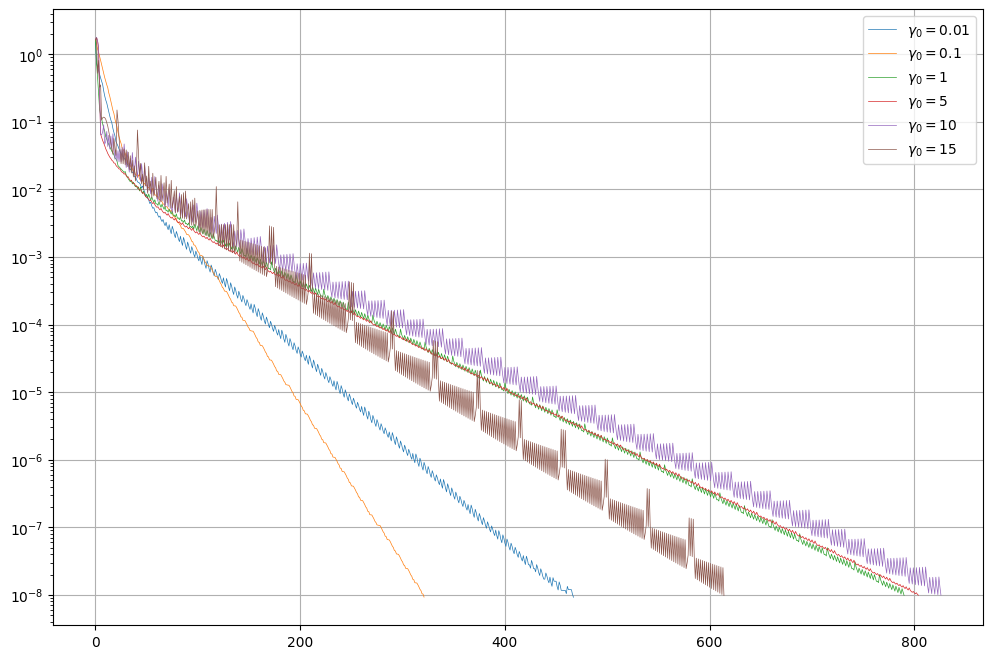

In [459]:
# Ваше решение (Code)
plt.figure(figsize=(12, 8))

gammas0 = [1e-2, 1/10, 1, 5, 10, 15]

for gamma0 in gammas0:

    _, _, errors = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, strong_wolfe, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, gamma0=gamma0, gamma_mult=0.5, beta1=1e-4, beta2=0.9, line_search_max_iter=20)
    
    iters = np.arange(len(errors))
    plt.plot(iters, errors, label=fr"$\gamma_0 = {gamma0}$", linewidth=0.5)
plt.yscale("log")
plt.legend()
plt.grid()

__д) (2 балла)__ Сделайте итоговое сравнение методов. Постройте график и укажите, какой оказался наиболее эффективным, для следующих методов: градиентный спуск с лучшим шагом, ускоренный градиентный метод с оптимальными параметрами или градиентный спуск с адаптивным шагом (Армихо, Гольдштейн, Вольф или усиленный Вольф).

In [461]:
# Ваше решение (Code)
eps=1e-8
max_iter = 1000

gamma_GD = lambda x: 2/(mu+L)
gamma = lambda x: 1/L
_, values_GD, errors_GD = gradient_descent(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=gamma_GD)

#tau_NAG = lambda x: 0.95*tau
_, values_NAG, errors_NAG = NAG(A_train, b_train, lambda_value, grad, criterion, x_0, eps, max_iter, gamma=gamma, tau=tau_ball)

_, _, errors_wolfe = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, wolfe, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, gamma0=0.1, gamma_mult=0.5, beta1=1e-4, beta2=0.9, line_search_max_iter=20)

_, _, errors_goldstein = gradient_descent_optimal_steps(A_train, b_train, lambda_value, loss, grad, goldstein, criterion, x_0, eps=1e-8, 
                                   max_iter=1000, gamma0=0.1, gamma_mult=0.5, beta1=0.1, beta2=1-0.1, line_search_max_iter=25)

  0%|          | 0/1000 [00:00<?, ?it/s]

 28%|██▊       | 285/1000 [00:06<00:16, 43.75it/s]


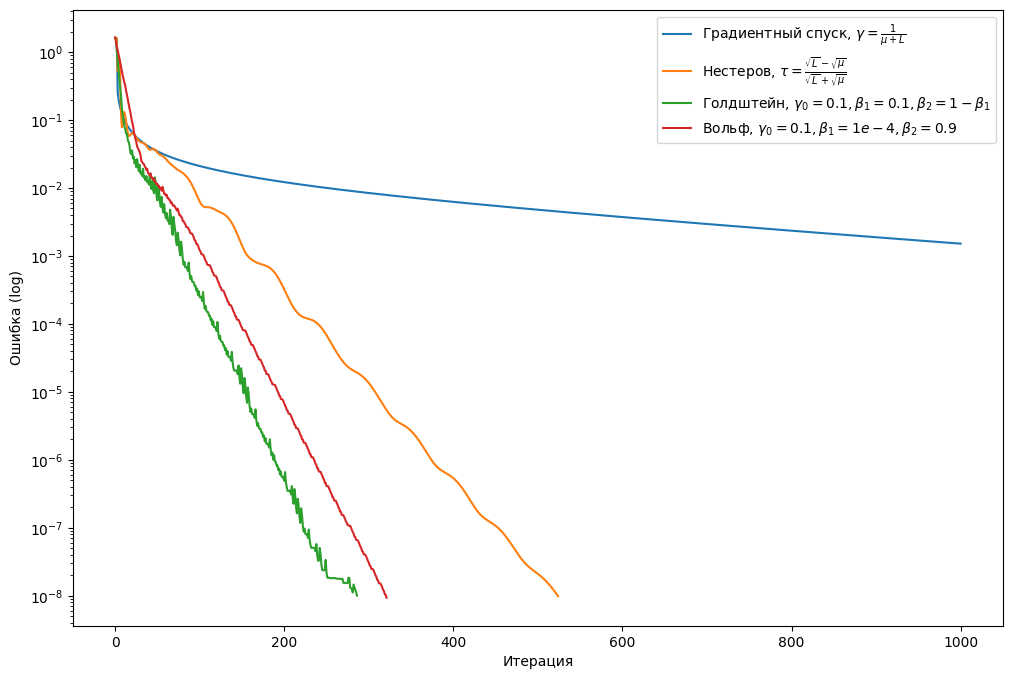

In [465]:
plt.figure(figsize=(12, 8))

iters = np.arange(len(errors_GD))
plt.plot(iters, errors_GD, label = r"Градиентный спуск, $\gamma = \frac{1}{\mu + L}$")
iters = np.arange(len(errors_NAG))
plt.plot(iters, errors_NAG, label=r"Нестеров, $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$")
iters = np.arange(len(errors_goldstein))
plt.plot(iters, errors_goldstein, label=r"Голдштейн, $\gamma_0 = 0.1, \beta_1 = 0.1, \beta_2 = 1 - \beta_1$")
iters = np.arange(len(errors_wolfe))
plt.plot(iters, errors_wolfe, label=r"Вольф, $\gamma_0 = 0.1, \beta_1 = 1e-4, \beta_2 = 0.9$")

plt.legend()
plt.xlabel("Итерация")
plt.ylabel("Ошибка (log)")
plt.yscale("log")